# Árvores de regressão - exercícios 01

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [2]:
import pandas as pd

import seaborn as sns

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split

df = pd.read_csv('housing.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [7]:
#Valores Ausentes
df.isnull().sum()

#Tipos de Colunas
df.dtypes

#Separando Variáveis
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

#Dividir Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

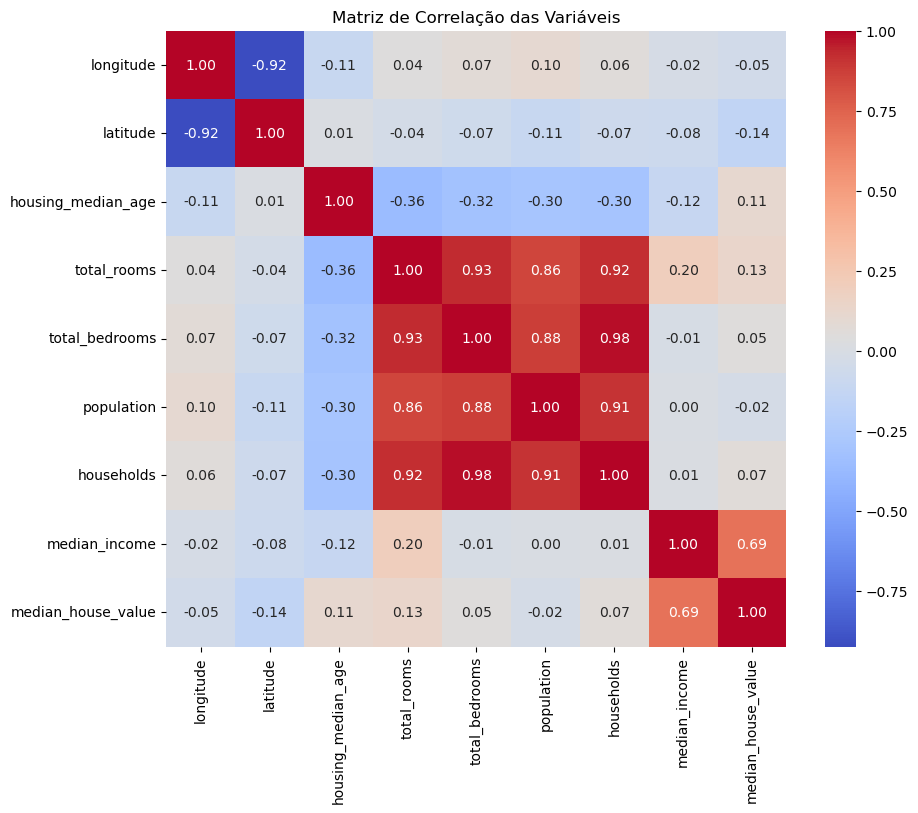

In [9]:
import matplotlib.pyplot as plt

# Calcula a matriz de correlação
correlacao = df.corr(numeric_only=True)

# Configura o tamanho do gráfico
plt.figure(figsize=(10, 8))

# Cria o heatmap
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de Correlação das Variáveis")
plt.show()

### 3. Separe os dados em validação e teste

In [11]:
# Pegamos o que sobrou do treino e dividimos novamente
# Aqui, 25% do treino vira validação (o que equivale a 20% do total original)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 12384 amostras
Validação: 4128 amostras
Teste: 4128 amostras


### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [13]:
# 1. Filtra apenas colunas numéricas (remove 'ocean_proximity' e outras strings)
X = df.drop('median_house_value', axis=1).select_dtypes(include=['number'])
y = df['median_house_value']

# 2. Refaça o split (importante para que X_train e X_test não tenham strings)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Se você estiver usando validação como sugerido no item 3:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

In [16]:
# Filtra apenas números e separa as variáveis
df_num = df.select_dtypes(include=['number'])
X = df_num.drop('median_house_value', axis=1)
y = df_num['median_house_value']

# Divide em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Árvore 2
regr_depth_2 = DecisionTreeRegressor(max_depth=2, random_state=42)
regr_depth_2.fit(X_train, y_train)

# Árvore 8
regr_depth_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
regr_depth_8.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [18]:
from sklearn.metrics import mean_squared_error

# MSE Profundidade 2
mse_train_2 = mean_squared_error(y_train, regr_depth_2.predict(X_train))
mse_test_2 = mean_squared_error(y_test, regr_depth_2.predict(X_test))

# MSE Profundidade 8
mse_train_8 = mean_squared_error(y_train, regr_depth_8.predict(X_train))
mse_test_8 = mean_squared_error(y_test, regr_depth_8.predict(X_test))

print(f"Árvore (Prof 2) - Treino: {mse_train_2:.2f} | Teste: {mse_test_2:.2f}")
print(f"Árvore (Prof 8) - Treino: {mse_train_8:.2f} | Teste: {mse_test_8:.2f}")

Árvore (Prof 2) - Treino: 7324946684.20 | Teste: 7542635096.03
Árvore (Prof 8) - Treino: 3261105657.27 | Teste: 4374020557.44


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

Árvore (Prof 2): Erro de treino e teste estão na casa dos 7.3 e 7.5 bilhões. Eles estão bem próximos, o que é bom, mas o erro é bem alto (modelo muito simples).

Árvore (Prof 8): O erro caiu drasticamente para a casa dos 3.2 bilhões (treino) e 4.3 bilhões (teste).

### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

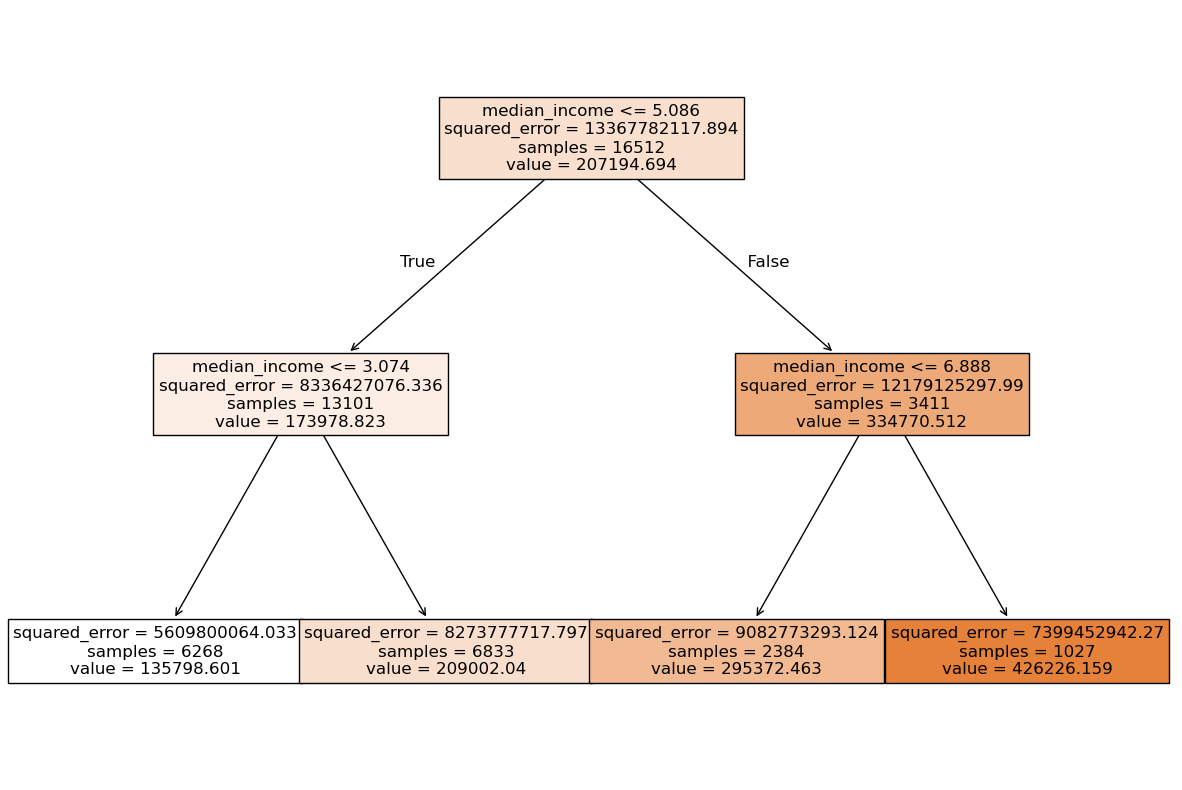

In [19]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15, 10))
tree.plot_tree(regr_depth_2, 
               feature_names=X.columns, 
               filled=True, 
               fontsize=12)
plt.show()